# Heterogeneous Causal Learning for Effectiveness Optimization

- 기존 uplift 모델은 이질적 처치 효과를 추정할 수 있지만, 비용 대비 이익을 충분히 반영하지 못합니다.

- 마케팅처럼 예산이 제한된 환경에서는, 비용을 고려하면서 효과를 최대화하는 처치 효과 최적화(treatment effect optimization) 접근이 필요합니다.

- 이를 위해 다음 알고리즘들을 활용합니다.
  - Duality R-learner
  - Direct Ranking Model (DRM)
  - Constrained Ranking Models

## Setup

In [1]:
%pip -q install fractional-uplift

Note: you may need to restart the kernel to use updated packages.


In [503]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

import fractional_uplift as fr 

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

import warnings
warnings.filterwarnings("ignore")


### CriteoWithSyntheticCostAndSpend Dataset


- CriteoWithSyntheticCostAndSpend 데이터는
  - treatment: 광고 노출 여부 (0/1)
  - spend: 고객이 발생시킨 매출(이익)
  - cost: 해당 고객에게 treatment를 줬을 때 발생한 고객별 비용

  을 모두 포함하므로, 비용까지 고려한 처치 최적화 실험에 적합합니다. 

- 주요 컬럼:
  - `treatment`: 광고/프로모션 노출 여부 (0/1)
  - `spend`: 사용자가 발생시킨 매출(이익) → Gain outcome: $(Y^r)$
  - `cost`: 해당 고객에게 treatment를 줄 때 들어간 비용 → Cost outcome: $(Y^c)$
  - `treatment_propensity`: 실험에서 treatment에 할당될 확률
  - `sample_weight`: 샘플 가중치
  - `criteo.features`: feature 컬럼 이름 리스트 (문자열 리스트)

- Train/Val/Test split:
  
  `train_data`를 train / validation / test 로 분리하여 사용합니다.
    

In [638]:
criteo = fr.example_data.CriteoWithSyntheticCostAndSpend.load()

df_all = criteo.train_data.copy()
features = criteo.features

# 1) train vs temp(=val+test)
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.4,              # val 0.2 + test 0.2
    random_state=RANDOM_STATE,
    stratify=df_all["treatment"],
)

# 2) temp를 val vs test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,              # temp의 절반 = 0.2
    random_state=RANDOM_STATE,
    stratify=temp_df["treatment"],
)

In [652]:
X_train = train_df[features].values.astype(np.float32)
X_val   = val_df[features].values.astype(np.float32)
X_test  = test_df[features].values.astype(np.float32)

T_train = train_df["treatment"].values.astype(int)
T_val   = val_df["treatment"].values.astype(int)
T_test  = test_df["treatment"].values.astype(int)

Yg_train = train_df["spend"].values.astype(float)  # gain
Yg_val   = val_df["spend"].values.astype(float)
Yg_test  = test_df["spend"].values.astype(float)

Yc_train = train_df["cost"].values.astype(float)   # cost
Yc_val   = val_df["cost"].values.astype(float)
Yc_test  = test_df["cost"].values.astype(float)

W_train = train_df["sample_weight"].values.astype(float)
W_val   = val_df["sample_weight"].values.astype(float)
W_test = test_df["sample_weight"].values.astype(float)

print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (43231, 12)
X_val   shape: (14411, 12)
X_test  shape: (14411, 12)


## Duality R-learner

Duality R-learner는 다음 두 단계를 결합한 방식입니다.

1. R-learner로 Gain/Cost CATE 추정
   - $\tau_r(x)$: gain uplift
   - $\tau_c(x)$: cost uplift

2. 예산 제약(budget constraint)을 듀얼 형태로 최적화
   - 라그랑지 승수 $\lambda$ 를 학습하여 최적 정책을 찾습니다.

우리가 풀고 싶은 문제는 다음과 같습니다.

- 예산 $B$ 하에서

  $$
  \max_{z_i \in \{0,1\}} \sum_i \tau_r(x^{(i)}) z_i
  \quad \text{s.t.} \quad
  \sum_i \tau_c(x^{(i)}) z_i \le B
  $$

- $z_i = 1$ 이면 고객 $i$ 에게 프로모션/광고를 집행, $z_i = 0$ 이면 미집행

Duality R-learner 핵심 단계:

1. Nuisance models: $m_r(x)$, $e(x)$ 학습  
2. Gain / Cost R-learner: $\tau_r(x)$, $\tau_c(x)$ 추정  
3. Duality: $\lambda$ 를 gradient ascent 로 최적화  
4. 정책 생성: $s(x) = \tau_r(x) - \lambda^* \tau_c(x)$
5. Cost Curve / AUCC 로 정책 성능 평가  


### 1. Nuisance Models: $m_r(x)$ 와 $e(x)$

R-learner는 아래 식을 기반으로 합니다.

$$
Y - m^*(X)
= (T - e^*(X))\,\tau^*(X) + \epsilon
$$

여기서  

- $m^*(X) = \mathbb{E}[Y \mid X]$: outcome 평균 모델  
- $e^*(X) = \mathbb{P}(T=1 \mid X)$: propensity score  
  > propensity score는 treatment_propensity 컬럼을 그대로 사용합니다.

- Gain outcome $Y^r = \texttt{spend}$
  - $m_r(x) = \mathbb{E}[Y^r\mid X=x]$: Ridge 회귀

- Cost outcome $Y^c = \texttt{cost}$
  - $m_c(x) = \mathbb{E}[Y^c\mid X=x]$: Ridge 회귀

In [620]:
# Gain outcome 평균 모델 m_r(x): Ridge 회귀
m_r = Ridge(alpha=1.0, random_state=RANDOM_STATE)
m_r.fit(X_train, Yg_train)

Yg_pred_train = m_r.predict(X_train)
Yg_pred_val   = m_r.predict(X_val)

r2_train_mr = r2_score(Yg_train, Yg_pred_train)
r2_val_mr   = r2_score(Yg_val,   Yg_pred_val)

print("== m_r(x) 성능 (R^2: spend 회귀) ==")
print("Train R^2:", r2_train_mr)
print("Val   R^2:", r2_val_mr)

print("\n예측값 분포 (Val):")
print(pd.Series(Yg_pred_val).describe())

== m_r(x) 성능 (R^2: spend 회귀) ==
Train R^2: 0.5937760649833947
Val   R^2: 0.6185973626734869

예측값 분포 (Val):
count    14411.000000
mean         7.721704
std         11.980173
min         -5.330875
25%         -0.231392
50%          1.539356
75%         12.941192
max         80.358582
dtype: float64


In [621]:
# Cost outcome 평균 모델 m_c(x): Ridge 회귀 (cost 전용 모델)
m_c = Ridge(alpha=1.0, random_state=RANDOM_STATE)
m_c.fit(X_train, Yc_train)

Yc_pred_train = m_c.predict(X_train)
Yc_pred_val   = m_c.predict(X_val)

r2_train_mc = r2_score(Yc_train, Yc_pred_train)
r2_val_mc   = r2_score(Yc_val,   Yc_pred_val)

print("== m_c(x) 성능 (R^2: cost 회귀) ==")
print("Train R^2:", r2_train_mc)
print("Val   R^2:", r2_val_mc)

print("\n예측값 분포 (Val):")
print(pd.Series(Yc_pred_val).describe())

== m_c(x) 성능 (R^2: cost 회귀) ==
Train R^2: 0.2921035090257208
Val   R^2: 0.27535410112615455

예측값 분포 (Val):
count    14411.000000
mean         2.570728
std          4.126056
min        -19.284588
25%         -0.116940
50%          0.918125
75%          4.393160
max         24.175064
dtype: float64


In [622]:
e_train = train_df["treatment_propensity"].values.astype(float)
e_val   = val_df["treatment_propensity"].values.astype(float)
e_test  = test_df["treatment_propensity"].values.astype(float)

auc_train_e = roc_auc_score(T_train, e_train)
auc_val_e   = roc_auc_score(T_val,   e_val)

print("== e(x) 성능 (AUC: treatment 모델) ==")
print("Train AUC:", auc_train_e)
print("Val   AUC:", auc_val_e)

print("\nPropensity e(x) range:")
print("Train:", e_train.min(), "→", e_train.max())
print("Val  :", e_val.min(),   "→", e_val.max())

== e(x) 성능 (AUC: treatment 모델) ==
Train AUC: 0.5
Val   AUC: 0.5

Propensity e(x) range:
Train: 0.8500001287591226 → 0.8500001287591226
Val  : 0.8500001287591226 → 0.8500001287591226


### 2. R-learner: Gain / Cost CATE 추정

Gain outcome $Y^r$ 에 대해 R-learner 구조는 다음과 같습니다.

$$
Y - m(X) = (T - e(X))\,\tau(X) + \epsilon
$$

선형 모델 $\tau(x) = w^\top x$ 를 쓰면:

1. **잔차 계산**
   $$
   r^Y = Y - \hat m(X), \quad r^T = T - \hat e(X)
   $$
2. **행 단위 스케일링**
   $$
   Z = X \odot r^T
   $$
3. **회귀**
   $$
   r^Y \approx Z w
   $$
4. **최종 CATE**
   $$
   \hat\tau(x) = w^\top x
   $$

이를 공통 함수로 구현하고,

- Gain R-learner: $Y = Y^r$, $m = m_r$
- Cost R-learner: $Y = Y^c$, $m = m_c$

로 각각 학습합니다.

In [623]:
def fit_r_learner_linear(
    X_tr, X_val,
    T_tr, T_val,
    Y_tr, Y_val,
    m_tr, m_val,
    e_tr, e_val,
    alpha=1.0,
    name="R-learner",
    rt_clip=1e-6,
):
    """
    선형 τ(x) = w^T x 를 R-learner 방식으로 학습.
    rY = (T - e(X)) * τ(X) + ε 를 이용해 w를 추정한다.
    """
    X_tr  = np.asarray(X_tr, dtype=float)
    X_val = np.asarray(X_val, dtype=float)
    T_tr  = np.asarray(T_tr, dtype=float)
    T_val = np.asarray(T_val, dtype=float)
    Y_tr  = np.asarray(Y_tr, dtype=float)
    Y_val = np.asarray(Y_val, dtype=float)
    m_tr  = np.asarray(m_tr, dtype=float)
    m_val = np.asarray(m_val, dtype=float)
    e_tr  = np.asarray(e_tr, dtype=float)
    e_val = np.asarray(e_val, dtype=float)

    # residuals
    rY_tr = Y_tr - m_tr
    rT_tr = T_tr - e_tr

    # rT가 너무 작은 경우 클리핑
    rT_tr = np.where(np.abs(rT_tr) < rt_clip, np.sign(rT_tr) * rt_clip, rT_tr)

    # Z = X * rT
    Z_tr = X_tr * rT_tr.reshape(-1, 1)

    # fit
    tau_model = Ridge(alpha=alpha, fit_intercept=False, random_state=RANDOM_STATE)
    tau_model.fit(Z_tr, rY_tr)

    # τ_hat(x) = w^T x
    w = tau_model.coef_.reshape(-1)
    tau_tr  = X_tr  @ w
    tau_val = X_val @ w

    # val에서 rY를 얼마나 설명하는지 확인
    rY_val = Y_val - m_val
    rT_val = T_val - e_val
    pred_rY_val = rT_val * tau_val
    mse_val = np.mean((rY_val - pred_rY_val) ** 2)

    print(f"== {name} 요약 ==")
    print("Train τ_hat summary:")
    print(pd.Series(tau_tr).describe())
    print("\nVal τ_hat summary:")
    print(pd.Series(tau_val).describe())
    print(f"\nVal check: MSE(rY, rT*tau) = {mse_val:.6f}")

    return tau_model, tau_tr, tau_val


In [624]:
# Gain R-learner: τ_r(x)
m_r_train = m_r.predict(X_train)
m_r_val   = m_r.predict(X_val)

tau_r_model, tau_r_train, tau_r_val = fit_r_learner_linear(
    X_tr=X_train,
    X_val=X_val,
    T_tr=T_train,
    T_val=T_val,
    Y_tr=Yg_train,
    Y_val=Yg_val,
    m_tr=m_r_train,
    m_val=m_r_val,
    e_tr=e_train,
    e_val=e_val,
    alpha=1.0,
    name="Gain R-learner τ_r(x)",
)

== Gain R-learner τ_r(x) 요약 ==
Train τ_hat summary:
count    43231.000000
mean         0.744968
std          4.095001
min        -14.967210
25%         -0.467654
50%          0.084019
75%          1.151731
max         75.742621
dtype: float64

Val τ_hat summary:
count    14411.000000
mean         0.805699
std          4.339214
min        -13.043869
25%         -0.465580
50%          0.088950
75%          1.189868
max         70.995090
dtype: float64

Val check: MSE(rY, rT*tau) = 91.237132


In [625]:
# Cost R-learner: τ_c(x)
m_c_train = m_c.predict(X_train)
m_c_val   = m_c.predict(X_val)

tau_c_model, tau_c_train, tau_c_val = fit_r_learner_linear(
    X_tr=X_train,
    X_val=X_val,
    T_tr=T_train,
    T_val=T_val,
    Y_tr=Yc_train,
    Y_val=Yc_val,
    m_tr=m_c_train,
    m_val=m_c_val,
    e_tr=e_train,
    e_val=e_val,
    alpha=1.0,
    name="Cost R-learner τ_c(x)",
)

== Cost R-learner τ_c(x) 요약 ==
Train τ_hat summary:
count    43231.000000
mean         2.810444
std          4.418757
min        -19.332760
25%         -0.070645
50%          0.982358
75%          4.749005
max         26.477165
dtype: float64

Val τ_hat summary:
count    14411.000000
mean         2.817899
std          4.431292
min        -20.013473
25%         -0.087577
50%          1.023093
75%          4.772627
max         25.653274
dtype: float64

Val check: MSE(rY, rT*tau) = 40.727902


In [626]:
# Test set CATE 예측
tau_r_test = X_test @ tau_r_model.coef_.reshape(-1)
tau_c_test = X_test @ tau_c_model.coef_.reshape(-1)

print("== τ_r(x) 요약 ==")
print("[Train]")
print(pd.Series(tau_r_train).describe())
print("\n[Val]")
print(pd.Series(tau_r_val).describe())
print("\n[Test]")
print(pd.Series(tau_r_test).describe())

print("\n== τ_c(x) 요약 ==")
print("[Train]")
print(pd.Series(tau_c_train).describe())
print("\n[Val]")
print(pd.Series(tau_c_val).describe())
print("\n[Test]")
print(pd.Series(tau_c_test).describe())


== τ_r(x) 요약 ==
[Train]
count    43231.000000
mean         0.744968
std          4.095001
min        -14.967210
25%         -0.467654
50%          0.084019
75%          1.151731
max         75.742621
dtype: float64

[Val]
count    14411.000000
mean         0.805699
std          4.339214
min        -13.043869
25%         -0.465580
50%          0.088950
75%          1.189868
max         70.995090
dtype: float64

[Test]
count    14411.000000
mean         0.713794
std          4.158598
min        -14.772031
25%         -0.479206
50%          0.054279
75%          1.114829
max         61.358405
dtype: float64

== τ_c(x) 요약 ==
[Train]
count    43231.000000
mean         2.810444
std          4.418757
min        -19.332760
25%         -0.070645
50%          0.982358
75%          4.749005
max         26.477165
dtype: float64

[Val]
count    14411.000000
mean         2.817899
std          4.431292
min        -20.013473
25%         -0.087577
50%          1.023093
75%          4.772627
max        

### 3. Duality: 예산 제약 하에서 $\lambda$ 최적화

목표는 다음과 같습니다.

$$
\begin{aligned}
\max_{z_i \in \{0,1\}}\quad & \sum_i \tau_r(x^{(i)}) z_i \\
\text{s.t.}\quad & \sum_i \tau_c(x^{(i)}) z_i \le B
\end{aligned}
$$

- $z_i = 1$: 고객 $i$ 타깃 (프로모션 발송)
- $B$: 사용할 수 있는 총 비용 예산

이를 위해 라그랑지 승수 $\lambda \ge 0$ 를 도입합니다.

$$
L(z, \lambda)
= -\sum_i \tau_r(x^{(i)}) z_i
  + \lambda\left(\sum_i \tau_c(x^{(i)}) z_i - B\right)
$$

고정된 $\lambda$ 에 대해:

$$
s_i(\lambda) = \tau_r(x^{(i)}) - \lambda\, \tau_c(x^{(i)})
$$

- $s_i(\lambda) \ge 0$ 이면 $z_i = 1$ (타깃)
- $s_i(\lambda) < 0$ 이면 $z_i = 0$ (비타깃)

듀얼 목적함수 기울기는

$$
\frac{\partial g}{\partial \lambda}
\approx \underbrace{\sum_i z_i\,\tau_c^+(x^{(i)})}_{\text{cost\_used}} - B
$$

이며, gradient ascent 업데이트는

$$
\lambda \leftarrow [\lambda + \eta(\text{cost\_used} - B)]_+
$$

- 예산 초과($\text{cost\_used} > B$) → $\lambda$ 증가 → cost가 큰 고객 penalize
- 예산 미만($\text{cost\_used} < B$) → $\lambda$ 감소 → 더 많은 고객 선택 허용

In [ ]:
def duality_learn_lambda(
    tau_r,
    tau_c,
    budget_fraction=0.3,
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
    scale=1e4
):
    """
    τ_r, τ_c 가 주어졌을 때 Duality gradient ascent로 λ 학습.
    - budget_fraction: 전체 양의 cost effect 합 중 몇 %를 예산으로 둘지
    """
    tau_r = np.asarray(tau_r).astype(float)
    tau_c = np.asarray(tau_c).astype(float)

    # 양의 cost effect만 예산 계산에 사용
    tau_c_pos = np.clip(tau_c, a_min=0.0, a_max=None)
    total_pos_cost = tau_c_pos.sum()
    B = budget_fraction * total_pos_cost

    lam = 0.0

    for it in range(n_iter + 1):
        # effectiveness score
        s = tau_r - lam * tau_c_pos

        # z_i: 선택 여부 (s_i >= 0 이면 선택)
        z = (s >= 0).astype(float)

        cost_used = (tau_c_pos * z).sum()
        gain_used = (np.clip(tau_r, 0.0, None) * z).sum()

        # ∂g/∂λ ≈ cost_used - B
        grad = cost_used - B

        # gradient ascent (λ >= 0 유지)
        lr_eff = lr * scale / (total_pos_cost + 1e-12)
        lam = max(0.0, lam + lr_eff * grad)

        if it % verbose_every == 0:
            sel_ratio = z.mean()
            print(
                f"[iter {it:03d}] λ={lam:.6f}, "
                f"cost_used={cost_used:.4f}, gain_used={gain_used:.4f}, "
                f"grad={grad:.4f}, selected={sel_ratio:.3f}"
            )

    print("\n최종 λ*:", lam)
    print("총 양의 cost effect 합:", total_pos_cost)
    print(f"예산 B (fraction={budget_fraction}):", B)
    return lam, B

In [628]:
# Train 데이터에서 λ* 학습
lambda_star, B_train = duality_learn_lambda(
    tau_r=tau_r_train,
    tau_c=tau_c_train,
    budget_fraction=0.3,  # 전체 양의 cost uplift 중 30%를 예산으로
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
    scale=1e4
)

[iter 000] λ=0.036519, cost_used=88238.3493, gain_used=56003.9532, grad=48442.7285, selected=0.530
[iter 020] λ=0.324064, cost_used=46207.1315, gain_used=49466.9730, grad=6411.5107, selected=0.363
[iter 040] λ=0.366826, cost_used=40887.6177, gain_used=47644.3566, grad=1091.9968, selected=0.333
[iter 060] λ=0.374218, cost_used=39912.3018, gain_used=47282.8494, grad=116.6809, selected=0.327
[iter 080] λ=0.374977, cost_used=39803.9172, gain_used=47242.2461, grad=8.2964, selected=0.326
[iter 100] λ=0.375001, cost_used=39795.3574, gain_used=47239.0362, grad=-0.2634, selected=0.326
[iter 120] λ=0.375001, cost_used=39795.3574, gain_used=47239.0362, grad=-0.2634, selected=0.326
[iter 140] λ=0.375002, cost_used=39795.3574, gain_used=47239.0362, grad=-0.2634, selected=0.326
[iter 160] λ=0.375002, cost_used=39795.3574, gain_used=47239.0362, grad=-0.2634, selected=0.326
[iter 180] λ=0.375003, cost_used=39795.3574, gain_used=47239.0362, grad=-0.2634, selected=0.326
[iter 200] λ=0.375003, cost_used=

In [642]:
def selection_summary(tau_r, tau_c, lam, name=""):
    tau_r = np.asarray(tau_r, float)
    tau_c = np.asarray(tau_c, float)
    tau_c_pos = np.clip(tau_c, 0.0, None)

    s = tau_r - lam * tau_c_pos
    z = (s >= 0).astype(float)

    gain_used = (tau_r * z).sum()
    cost_used = (tau_c_pos * z).sum()
    sel_ratio = z.mean()
    ratio = gain_used / cost_used if cost_used > 0 else np.nan

    print(f"\n== Selection summary ({name}) ==")
    print(f"λ = {lam:.6f}")
    print(f"선택 비율: {sel_ratio:.3f}  ({z.sum():.0f} / {len(z)})")
    print(f"총 gain (∑ τ_r z): {gain_used:.4f}")
    print(f"총 cost (∑ τ_c^+ z): {cost_used:.4f}")
    print(f"gain / cost 비율: {ratio:.4f}")

    return {"lambda": lam, "selected_ratio": sel_ratio, "gain_used": gain_used, "cost_used": cost_used, "gain_per_cost": ratio}


In [643]:
_ = selection_summary(tau_r_train, tau_c_train, lambda_star, name="Train")
_ = selection_summary(tau_r_val,   tau_c_val,   lambda_star, name="Val")
_ = selection_summary(tau_r_test,  tau_c_test,  lambda_star, name="Test")


== Selection summary (Train) ==
λ = 0.375003
선택 비율: 0.326  (14100 / 43231)
총 gain (∑ τ_r z): 47239.0362
총 cost (∑ τ_c^+ z): 39795.3574
gain / cost 비율: 1.1870

== Selection summary (Val) ==
λ = 0.375003
선택 비율: 0.328  (4733 / 14411)
총 gain (∑ τ_r z): 16722.9333
총 cost (∑ τ_c^+ z): 13560.8063
gain / cost 비율: 1.2332

== Selection summary (Test) ==
λ = 0.375003
선택 비율: 0.323  (4656 / 14411)
총 gain (∑ τ_r z): 15984.1864
총 cost (∑ τ_c^+ z): 12859.2200
gain / cost 비율: 1.2430


### 4. Cost Curve & AUCC (Test set 평가)

Test 셋에서 정책의 성능을 Incremental Cost 대비 Incremental Gain 곡선으로 평가합니다.

1. **Effectiveness score로 정렬** 

   Duality R-learner의 점수는
   $$
   s(x)=\tau_r(x)-\lambda^*\tau_c(x)
   $$
   로 정의하며, 이를 기준으로 샘플을 내림차순으로 정렬합니다.

2. **상위 \(k\)명(prefix)에서 ATE 추정**  

   정렬된 상위 \(k\)개 집단에서 관측 결과 \(Y\)를 사용해 gain과 cost에 대한 ATE를 계산합니다:
   $$
   \widehat{ATE}_g(k)=\mathbb{E}[Y_g\mid T=1]-\mathbb{E}[Y_g\mid T=0],\quad
   \widehat{ATE}_c(k)=\mathbb{E}[Y_c\mid T=1]-\mathbb{E}[Y_c\mid T=0].
   $$

3. **총 증분 gain/cost 계산**  
   상위 \(k\) 집단에서 실제 처치된 샘플 수 \(n_t(k)\)를 곱해,
   $$
   \Delta G(k)=n_t(k)\cdot \widehat{ATE}_g(k),\quad
   \Delta C(k)=n_t(k)\cdot \widehat{ATE}_c(k)
   $$
   를 각 점으로 사용합니다.

4. **정규화 및 Cost Curve 구성**  
   \((0,0)\)을 포함한 $(\Delta C(k), \Delta G(k))$를 정규화하여
   $$
   x(k)=\frac{\Delta C(k)}{C_{\text{norm}}},\quad
   y(k)=\frac{\Delta G(k)}{G_{\text{norm}}}
   $$
   로 변환하고, 이를 이은 곡선을 Cost Curve로 정의합니다.  
   정규화 기준은 전체 집단을 기본으로 사용하되, 전원 처리 시 증분 gain이 0 이하인 경우에는
   **양수 구간의 최대값(max-positive)**을 사용하여 비교 가능하게 합니다.

5. **AUCC 계산**  
   Cost Curve 아래 면적을 수치 적분으로 계산합니다:
   $$
   \text{AUCC}=\int_0^1 y(x)\,dx.
   $$


In [654]:
def cost_curve_aucc(scores, Yg, Yc, T, W=None, n_points=80, clip_negative_gain=False):
    scores = np.asarray(scores, float)
    Yg = np.asarray(Yg, float)
    Yc = np.asarray(Yc, float)
    T  = np.asarray(T, int)
    if W is None:
        W = np.ones_like(T, dtype=float)
    else:
        W = np.asarray(W, float)

    order = np.argsort(-scores)
    Yg, Yc, T, W = Yg[order], Yc[order], T[order], W[order]

    N  = len(T)
    ks = np.linspace(1, N, n_points, dtype=int)

    def wmean(y, w):
        return (y * w).sum() / (w.sum() + 1e-12)

    inc_g, inc_c = [0.0], [0.0]
    for k in ks:
        T_k, Yg_k, Yc_k, W_k = T[:k], Yg[:k], Yc[:k], W[:k]
        mt, mc = (T_k == 1), (T_k == 0)

        if mt.sum() == 0 or mc.sum() == 0:
            inc_g.append(0.0); inc_c.append(0.0); continue

        ate_g = wmean(Yg_k[mt], W_k[mt]) - wmean(Yg_k[mc], W_k[mc])
        ate_c = wmean(Yc_k[mt], W_k[mt]) - wmean(Yc_k[mc], W_k[mc])

        
        w_t = W_k[mt].sum()
        inc_g.append(ate_g * w_t)
        inc_c.append(ate_c * w_t)

    inc_g = np.asarray(inc_g, float)
    if clip_negative_gain:
        inc_g = np.maximum(inc_g, 0.0)

    # cost는 음수면 0으로 (안전)
    inc_c = np.maximum(np.asarray(inc_c, float), 0.0)

    max_g, max_c = inc_g[-1], inc_c[-1]
    if max_g == 0:
        max_g = np.max(np.abs(inc_g)) if np.max(np.abs(inc_g)) > 0 else 1.0
    if max_c == 0:
        max_c = np.max(inc_c) if np.max(inc_c) > 0 else 1.0

    x = inc_c / max_c
    y = inc_g / max_g

    x = np.maximum.accumulate(x)
    aucc = np.trapz(y, x)
    return x, y, aucc


In [655]:
def plot_cost_curve(x, y, aucc, title="Cost Curve", label="Model"):
    plt.figure(figsize=(7, 6))
    plt.plot(x, y, label=f"{label} (AUCC={aucc:.3f})")
    plt.plot([0, 1], [0, 1], alpha=0.35, linewidth=1, label="y=x benchmark")
    plt.xlabel("Incremental cost (normalized)")
    plt.ylabel("Incremental gain (normalized)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Duality AUCC: 0.6109516208594291


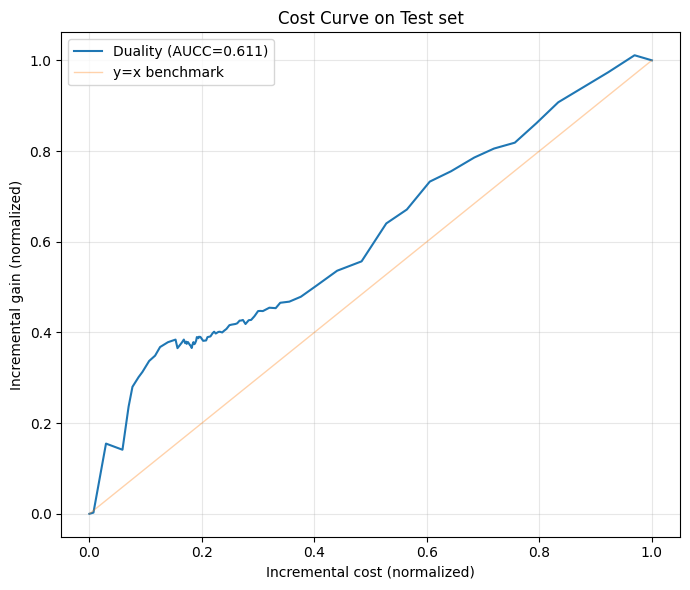

In [656]:
tau_c_test_pos = np.clip(tau_c_test, 0.0, None)
scores_duality = tau_r_test - lambda_star * tau_c_test_pos
x, y, aucc = cost_curve_aucc(scores_duality, Yg_test, Yc_test, T_test, W=W_test, n_points=80)


print("Duality AUCC:", aucc)
plot_cost_curve(x, y, aucc, title="Cost Curve on Test set", label="Duality")

In [651]:
def cost_used_under_policy(tau_r, tau_c, lam):
    tc = np.clip(tau_c, 0.0, None)
    s  = tau_r - lam * tc
    z  = (s >= 0).astype(float)
    return (tc * z).sum(), z.mean()

for name, tr, tc in [("train", tau_r_train, tau_c_train),
                     ("val",   tau_r_val,   tau_c_val),
                     ("test",  tau_r_test,  tau_c_test)]:
    c, sel = cost_used_under_policy(tr, tc, lambda_star)
    print(name, "cost_used:", c, "selected:", sel)
print("B_train:", B_train)


train cost_used: 39795.357426534225 selected: 0.32615484258980826
val cost_used: 13560.806268071696 selected: 0.3284296717785025
test cost_used: 12859.22000170533 selected: 0.32308653112205954
B_train: 39795.62082785283
